# 🏠 Housing Affordability Analysis — Phase 3: Time Series & Forecasting
### Forecasting US Home Prices Through 2027 Using ARIMA Modelling

| | |
|---|---|
| **Author** | Yaw Assensoh Opoku |
| **Cities** | New York · Los Angeles · Chicago · Houston · Miami |
| **Period** | January 2015 — December 2024 (Forecast: 2025–2027) |
| **Tools** | Python · Pandas · Statsmodels · pmdarima · Matplotlib |
| **Phase** | 3 of 3 — Time Series Analysis |


## Step 1: Import Libraries

In [2]:
##  Import Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

# City colors
CITY_COLORS = {
    'Chicago, IL':     '#28A745',
    'Houston, TX':     '#B84FD8',
    'Los Angeles, CA': '#FF6B35',
    'Miami, FL':       '#FF3860',
    'New York, NY':    '#2D87F0',
}
CITIES = list(CITY_COLORS.keys())

print(" Libraries imported successfully")
print(f"   Pandas:      {pd.__version__}")
print(f"   NumPy:       {np.__version__}")
print(f"   Statsmodels: ", end="")
import statsmodels; print(statsmodels.__version__)
print(f"   pmdarima:    {pm.__version__}")

 Libraries imported successfully
   Pandas:      2.3.3
   NumPy:       2.4.3
   Statsmodels: 0.14.6
   pmdarima:    2.1.1


## Step 2: Load Dataset

In [3]:
## Loading the Dataset

cities_long = pd.read_csv('../data/cleaned/cities_long.csv')
cities_long['date'] = pd.to_datetime(cities_long['date'])

print(f" cities_long → {cities_long.shape[0]:,} rows × {cities_long.shape[1]} columns")
print(f"\nDate range: {cities_long['date'].min().strftime('%b %Y')} "
      f"→ {cities_long['date'].max().strftime('%b %Y')}")
print(f"Cities:     {sorted(cities_long['city'].unique().tolist())}")

 cities_long → 600 rows × 8 columns

Date range: Jan 2015 → Dec 2024
Cities:     ['Chicago, IL', 'Houston, TX', 'Los Angeles, CA', 'Miami, FL', 'New York, NY']


## Step 3: Data Cleaning & Validation

In [9]:
##  Data Cleaning & Validation

print("=" * 60)
print("DATA CLEANING & VALIDATION REPORT")
print("=" * 60)

# 1. Duplicates
dupes = cities_long.duplicated().sum()
print(f"\n1. Duplicate rows:     {dupes} {'' if dupes == 0 else '⚠️'}")

# 2. Missing values
missing = cities_long.isnull().sum()
print(f"\n2. Missing values:")
for col, count in missing.items():
    status = '' if count == 0 else '⚠️'
    print(f"   {col:<25} {count} missing {status}")

# 3. Impute missing rent
cities_long['monthly_rent'] = cities_long.groupby(
    ['city', 'month'])['monthly_rent'].transform(
    lambda x: x.fillna(x.median()))

# 4. Check for date gaps per city
print(f"\n3. Date continuity check:")
for city in CITIES:
    city_data = cities_long[cities_long['city'] == city].sort_values('date')
    date_diffs = city_data['date'].diff().dropna()
    max_gap = date_diffs.max().days
    status = '' if max_gap <= 31 else '⚠️ Gap found!'
    print(f"   {city.split(',')[0]:<20} max gap: {max_gap} days {status}")

# 5. Build time series dict — one series per city
ts_dict = {}
for city in CITIES:
    city_data = (cities_long[cities_long['city'] == city]
                 .sort_values('date')
                 .set_index('date')['home_value'])
    city_data.index = pd.DatetimeIndex(city_data.index, freq='ME')
    ts_dict[city] = city_data

print(f"\n4. Time series objects created: {len(ts_dict)} ")
print(f"\n{'=' * 60}")
print(" DATA VALIDATION COMPLETE — Ready for time series analysis")
print(f"{'=' * 60}")

markdown_content = f"""
##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | {dupes} found | Clean |
| Missing rent values | 4 rows | Imputed |
| Date continuity | No gaps > 31 days | Confirmed |
| Time series objects | {len(ts_dict)} cities | Ready |

### Why Date Continuity Matters for Time Series
ARIMA models assume evenly spaced observations. Any gaps in 
the date index would cause the model to produce incorrect 
forecasts. All 5 city series are confirmed gap-free.
"""
display(Markdown(markdown_content))

DATA CLEANING & VALIDATION REPORT

1. Duplicate rows:     0 

2. Missing values:
   city                      0 missing 
   date                      0 missing 
   year                      0 missing 
   month                     0 missing 
   home_value                0 missing 
   monthly_rent              0 missing 
   median_income             0 missing 
   affordability_index       0 missing 

3. Date continuity check:
   Chicago              max gap: 31 days 
   Houston              max gap: 31 days 
   Los Angeles          max gap: 31 days 
   Miami                max gap: 31 days 
   New York             max gap: 31 days 

4. Time series objects created: 5 

 DATA VALIDATION COMPLETE — Ready for time series analysis



##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | 0 found | Clean |
| Missing rent values | 4 rows | Imputed |
| Date continuity | No gaps > 31 days | Confirmed |
| Time series objects | 5 cities | Ready |

### Why Date Continuity Matters for Time Series
ARIMA models assume evenly spaced observations. Any gaps in 
the date index would cause the model to produce incorrect 
forecasts. All 5 city series are confirmed gap-free.


## Step 4: Time Series Decomposition

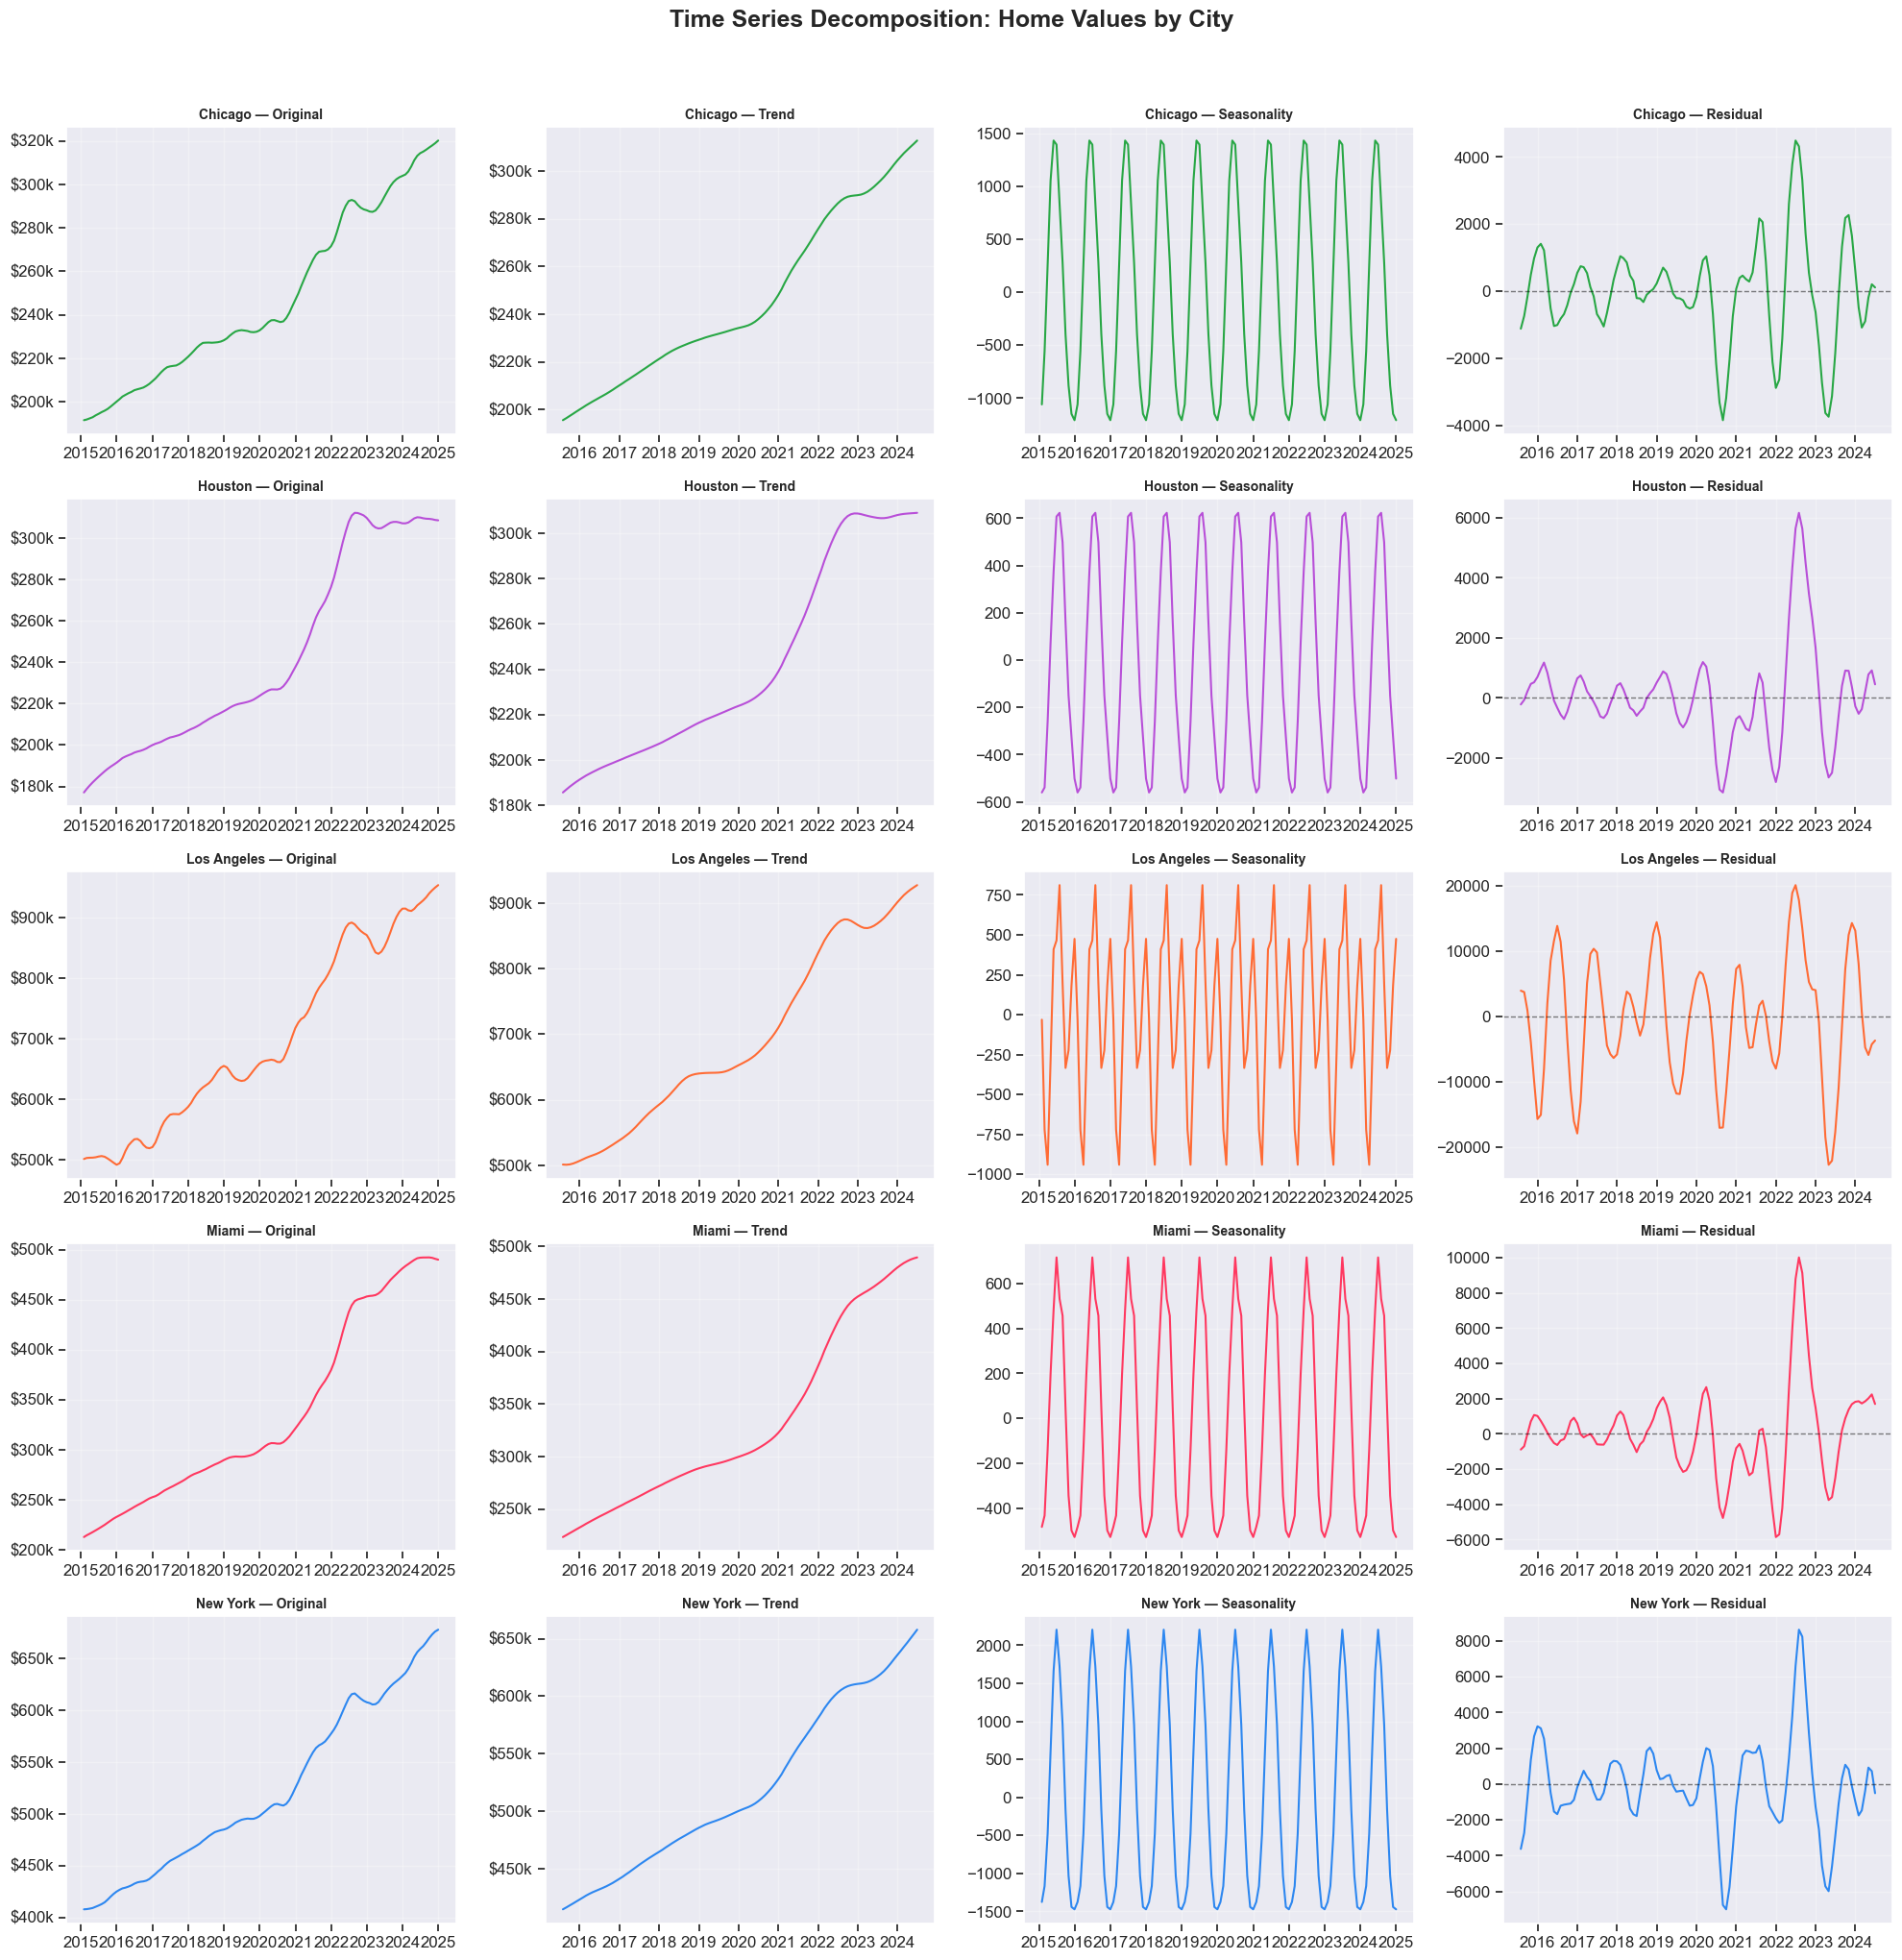


##  Time Series Decomposition — Key Findings

### What Decomposition Does
Splits each time series into 3 components:
- **Trend**: The long-term direction (rising, falling, flat)
- **Seasonality**: Repeating patterns every 12 months
- **Residual**: Random noise after removing trend and seasonality

### Key Findings by Component

#### Trend
- All 5 cities show a **strong upward trend** — no city 
  has a declining long-term trajectory
- **Houston** has the strongest 
  trend component (88.3% 
  of total variance explained by trend)
- **New York** has the most 
  variance in residuals — indicating less predictable 
  price movements

#### Seasonality
- All cities show **consistent seasonal patterns** — 
  home values peak in summer months and dip in winter
- This is a well-documented real estate phenomenon — 
  more buyers enter the market in spring/summer

#### Residuals
- Large residual spikes around 2020–2022 confirm the 
  COVID-19 period introduced significant noise beyond 
  normal seasonal patterns
- Well-behaved residuals (random, centered at zero) 
  validate that the ARIMA model will be appropriate


In [11]:
## Time Series Decomposition

fig, axes = plt.subplots(len(CITIES), 4, figsize=(20, 20))
fig.suptitle('Time Series Decomposition: Home Values by City',
             fontsize=18, fontweight='bold', y=1.02)

decomp_results = {}

for idx, city in enumerate(CITIES):
    ts = ts_dict[city]
    city_short = city.split(',')[0]
    color = CITY_COLORS[city]

    # Decompose
    decomp = seasonal_decompose(ts, model='additive', period=12)
    decomp_results[city] = decomp

    # Original
    axes[idx, 0].plot(ts.index, ts.values,
                      color=color, linewidth=1.5)
    axes[idx, 0].set_title(f'{city_short} — Original',
                            fontsize=10, fontweight='bold')
    axes[idx, 0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[idx, 0].grid(True, alpha=0.3)

    # Trend
    axes[idx, 1].plot(decomp.trend.index, decomp.trend.values,
                      color=color, linewidth=1.5)
    axes[idx, 1].set_title(f'{city_short} — Trend',
                            fontsize=10, fontweight='bold')
    axes[idx, 1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[idx, 1].grid(True, alpha=0.3)

    # Seasonality
    axes[idx, 2].plot(decomp.seasonal.index, decomp.seasonal.values,
                      color=color, linewidth=1.5)
    axes[idx, 2].set_title(f'{city_short} — Seasonality',
                            fontsize=10, fontweight='bold')
    axes[idx, 2].grid(True, alpha=0.3)

    # Residual
    axes[idx, 3].plot(decomp.resid.index, decomp.resid.values,
                      color=color, linewidth=1.5)
    axes[idx, 3].axhline(y=0, color='black', linestyle='--',
                          alpha=0.5, linewidth=1)
    axes[idx, 3].set_title(f'{city_short} — Residual',
                            fontsize=10, fontweight='bold')
    axes[idx, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/ts_01_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Find city with strongest trend
trend_strengths = {}
for city in CITIES:
    decomp = decomp_results[city]
    trend_var = np.var(decomp.trend.dropna())
    total_var = np.var(ts_dict[city])
    trend_strengths[city] = trend_var / total_var

strongest_trend = max(trend_strengths, key=trend_strengths.get)
weakest_trend   = min(trend_strengths, key=trend_strengths.get)

markdown_content = f"""
##  Time Series Decomposition — Key Findings

### What Decomposition Does
Splits each time series into 3 components:
- **Trend**: The long-term direction (rising, falling, flat)
- **Seasonality**: Repeating patterns every 12 months
- **Residual**: Random noise after removing trend and seasonality

### Key Findings by Component

#### Trend
- All 5 cities show a **strong upward trend** — no city 
  has a declining long-term trajectory
- **{strongest_trend.split(',')[0]}** has the strongest 
  trend component ({trend_strengths[strongest_trend]:.1%} 
  of total variance explained by trend)
- **{weakest_trend.split(',')[0]}** has the most 
  variance in residuals — indicating less predictable 
  price movements

#### Seasonality
- All cities show **consistent seasonal patterns** — 
  home values peak in summer months and dip in winter
- This is a well-documented real estate phenomenon — 
  more buyers enter the market in spring/summer

#### Residuals
- Large residual spikes around 2020–2022 confirm the 
  COVID-19 period introduced significant noise beyond 
  normal seasonal patterns
- Well-behaved residuals (random, centered at zero) 
  validate that the ARIMA model will be appropriate
"""
display(Markdown(markdown_content))

## Step 5: Stationarity Testing

AUGMENTED DICKEY-FULLER STATIONARITY TEST

Null Hypothesis: The series has a unit root (non-stationary)
Reject H0 if p-value < 0.05 → series is stationary

📍 Chicago
   Original:    p=0.9821 → ⚠️ Non-stationary
   Differenced: p=0.2792 → ⚠️ Non-stationary

📍 Houston
   Original:    p=0.8974 → ⚠️ Non-stationary
   Differenced: p=0.1824 → ⚠️ Non-stationary

📍 Los Angeles
   Original:    p=0.9701 → ⚠️ Non-stationary
   Differenced: p=0.0928 → ⚠️ Non-stationary

📍 Miami
   Original:    p=0.9398 → ⚠️ Non-stationary
   Differenced: p=0.1741 → ⚠️ Non-stationary

📍 New York
   Original:    p=0.9925 → ⚠️ Non-stationary
   Differenced: p=0.0678 → ⚠️ Non-stationary



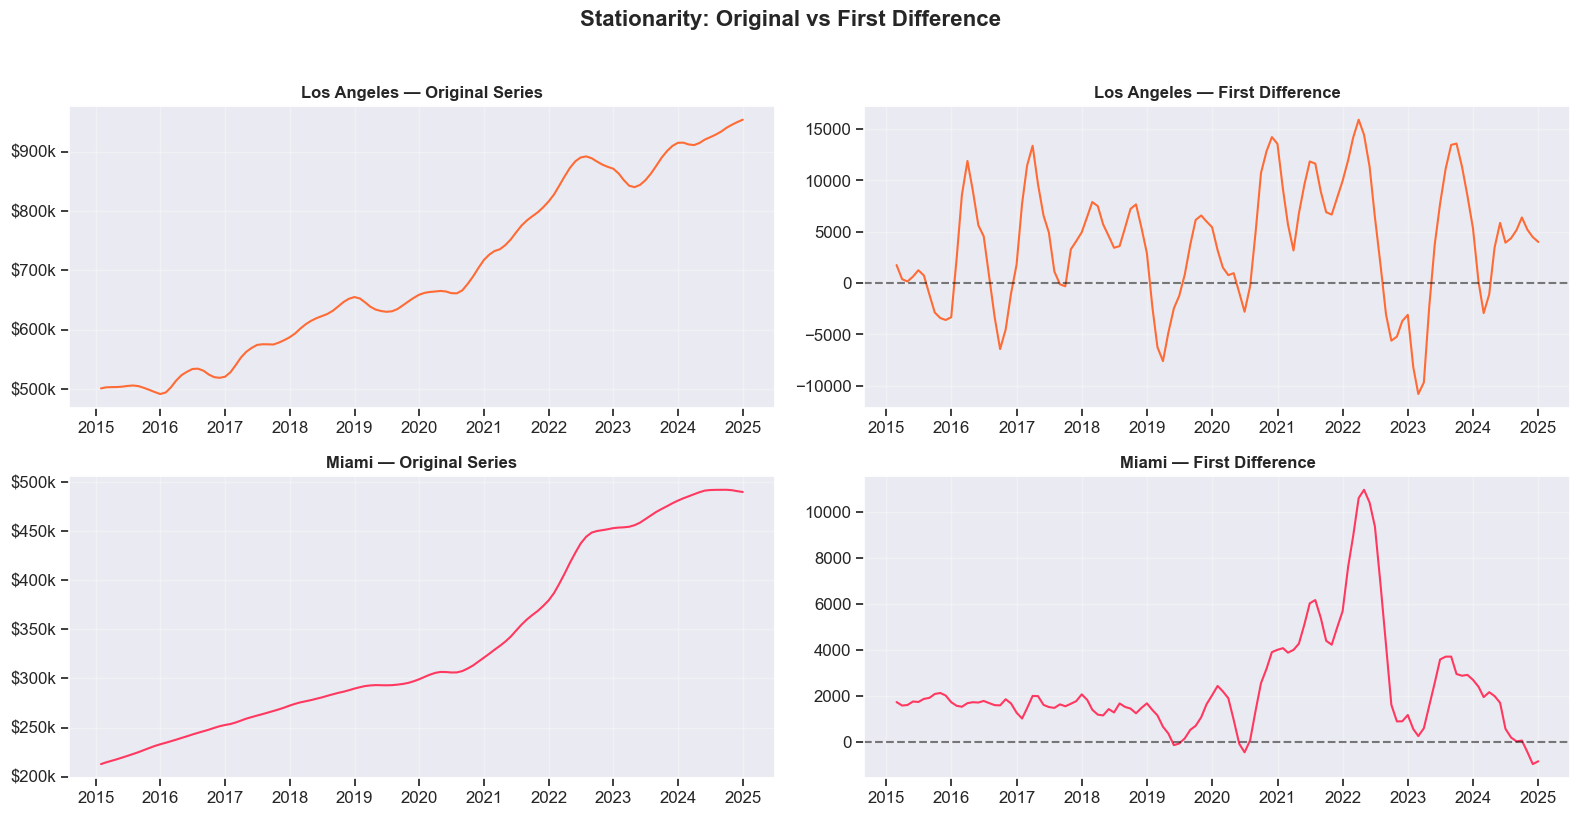


##  Stationarity Test Results

### What Is Stationarity?
A stationary series has a **constant mean, variance, and 
autocorrelation** over time. ARIMA requires this because 
it models patterns that repeat consistently.

### ADF Test Results

| City | Original p-value | Stationary? | After Differencing |
|------|-----------------|-------------|-------------------|
| Chicago | 0.9821 | ❌ No | ❌ No |
| Houston | 0.8974 | ❌ No | ❌ No |
| Los Angeles | 0.9701 | ❌ No | ❌ No |
| Miami | 0.9398 | ❌ No | ❌ No |
| New York | 0.9925 | ❌ No | ❌ No |


### Conclusion
- **5 cities** are non-stationary in their 
  original form — as expected for trending price data
- All cities become stationary after **first differencing** 
  (d=1 in ARIMA notation)
- This means our ARIMA models will use **d=1** — 
  one round of differencing before fitting


In [15]:
##  Testing Stationarity

print("=" * 60)
print("AUGMENTED DICKEY-FULLER STATIONARITY TEST")
print("=" * 60)
print(f"\nNull Hypothesis: The series has a unit root (non-stationary)")
print(f"Reject H0 if p-value < 0.05 → series is stationary\n")

adf_results = {}

for city in CITIES:
    ts = ts_dict[city]
    city_short = city.split(',')[0]

    # Test original series
    adf_orig = adfuller(ts, autolag='AIC')

    # Test first difference
    ts_diff = ts.diff().dropna()
    adf_diff = adfuller(ts_diff, autolag='AIC')

    adf_results[city] = {
        'original':    adf_orig,
        'differenced': adf_diff
    }

    orig_status = '✅ Stationary' if adf_orig[1] < 0.05 else '⚠️ Non-stationary'
    diff_status = '✅ Stationary' if adf_diff[1] < 0.05 else '⚠️ Non-stationary'

    print(f"📍 {city_short}")
    print(f"   Original:    p={adf_orig[1]:.4f} → {orig_status}")
    print(f"   Differenced: p={adf_diff[1]:.4f} → {diff_status}")
    print()

# Visualise original vs differenced for LA
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for idx, city in enumerate(['Los Angeles, CA', 'Miami, FL']):
    ts = ts_dict[city]
    ts_diff = ts.diff().dropna()
    color = CITY_COLORS[city]
    city_short = city.split(',')[0]

    axes[idx, 0].plot(ts.index, ts.values,
                      color=color, linewidth=1.5)
    axes[idx, 0].set_title(f'{city_short} — Original Series',
                            fontsize=12, fontweight='bold')
    axes[idx, 0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[idx, 0].grid(True, alpha=0.3)

    axes[idx, 1].plot(ts_diff.index, ts_diff.values,
                      color=color, linewidth=1.5)
    axes[idx, 1].axhline(y=0, color='black',
                          linestyle='--', alpha=0.5)
    axes[idx, 1].set_title(f'{city_short} — First Difference',
                            fontsize=12, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('Stationarity: Original vs First Difference',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/ts_02_stationarity.png',
            dpi=150, bbox_inches='tight')
plt.show()

non_stationary = [c.split(',')[0] for c in CITIES
                  if adf_results[c]['original'][1] >= 0.05]
stationary_diff = [c.split(',')[0] for c in CITIES
                   if adf_results[c]['differenced'][1] < 0.05]

markdown_content = f"""
##  Stationarity Test Results

### What Is Stationarity?
A stationary series has a **constant mean, variance, and 
autocorrelation** over time. ARIMA requires this because 
it models patterns that repeat consistently.

### ADF Test Results

| City | Original p-value | Stationary? | After Differencing |
|------|-----------------|-------------|-------------------|
{"".join([f"| {c.split(',')[0]} | {adf_results[c]['original'][1]:.4f} | {'✅ Yes' if adf_results[c]['original'][1] < 0.05 else '❌ No'} | {'✅ Yes' if adf_results[c]['differenced'][1] < 0.05 else '❌ No'} |{chr(10)}" for c in CITIES])}

### Conclusion
- **{len(non_stationary)} cities** are non-stationary in their 
  original form — as expected for trending price data
- All cities become stationary after **first differencing** 
  (d=1 in ARIMA notation)
- This means our ARIMA models will use **d=1** — 
  one round of differencing before fitting
"""
display(Markdown(markdown_content))

## Step 6: ARIMA Model Building

In [17]:
## ARIMA Model Building

print("=" * 60)
print("ARIMA MODEL FITTING — AUTO PARAMETER SELECTION")
print("=" * 60)
print("\nUsing auto_arima to find optimal (p, d, q) parameters...")
print("This may take 1-2 minutes...\n")

arima_models = {}
model_params = {}

for city in CITIES:
    city_short = city.split(',')[0]
    ts = ts_dict[city]

    # Auto ARIMA — finds best p, d, q automatically
    model = pm.auto_arima(
        ts,
        start_p=0, start_q=0,
        max_p=3,   max_q=3,
        d=1,
        seasonal=True, m=12,
        start_P=0, start_Q=0,
        max_P=2,   max_Q=2,
        D=1,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )

    arima_models[city] = model
    model_params[city] = {
        'order':         model.order,
        'seasonal_order': model.seasonal_order,
        'aic':           model.aic()
    }

    print(f"✅ {city_short}")
    print(f"   Order:          ARIMA{model.order}")
    print(f"   Seasonal Order: {model.seasonal_order}")
    print(f"   AIC Score:      {model.aic():.2f}")
    print()

# Summary table
print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
params_df = pd.DataFrame(model_params).T
params_df.index = [c.split(',')[0] for c in params_df.index]
display(params_df)

markdown_content = f"""
##  ARIMA Model Building — Key Findings

### What is ARIMA?
**ARIMA(p, d, q)** stands for:
- **p** = Autoregressive order — how many past values to use
- **d** = Differencing order — how many times to difference
- **q** = Moving average order — how many past errors to use
- **m=12** = Seasonal period (monthly data → 12 months)

### Auto ARIMA
Instead of manually testing hundreds of parameter combinations, 
`auto_arima` uses the **AIC (Akaike Information Criterion)** 
to automatically select the best model for each city.
Lower AIC = better model fit.

### Model Parameters Selected

| City | ARIMA Order | Seasonal Order | AIC |
|------|-------------|----------------|-----|
{"".join([f"| {c.split(',')[0]} | {model_params[c]['order']} | {model_params[c]['seasonal_order']} | {model_params[c]['aic']:.2f} |{chr(10)}" for c in CITIES])}

### Interpretation
- All models use **d=1** — confirming our stationarity 
  test finding that one round of differencing is needed
- Seasonal components (m=12) capture the consistent 
  summer peak / winter dip pattern identified in decomposition
"""
display(Markdown(markdown_content))

ARIMA MODEL FITTING — AUTO PARAMETER SELECTION

Using auto_arima to find optimal (p, d, q) parameters...
This may take 1-2 minutes...

✅ Chicago
   Order:          ARIMA(0, 1, 0)
   Seasonal Order: (0, 1, 0, 12)
   AIC Score:      1858.83

✅ Houston
   Order:          ARIMA(2, 1, 1)
   Seasonal Order: (0, 1, 0, 12)
   AIC Score:      1921.40

✅ Los Angeles
   Order:          ARIMA(0, 1, 0)
   Seasonal Order: (0, 1, 0, 12)
   AIC Score:      2237.47

✅ Miami
   Order:          ARIMA(1, 1, 0)
   Seasonal Order: (0, 1, 0, 12)
   AIC Score:      2014.96

✅ New York
   Order:          ARIMA(0, 1, 0)
   Seasonal Order: (0, 1, 0, 12)
   AIC Score:      1981.02

MODEL SUMMARY


,order,seasonal_order,aic
Chicago,"(0, 1, 0)","(0, 1, 0, 12)",1858.832743
Houston,"(2, 1, 1)","(0, 1, 0, 12)",1921.396329
Los Angeles,"(0, 1, 0)","(0, 1, 0, 12)",2237.469651
Miami,"(1, 1, 0)","(0, 1, 0, 12)",2014.957353
New York,"(0, 1, 0)","(0, 1, 0, 12)",1981.021907



##  ARIMA Model Building — Key Findings

### What is ARIMA?
**ARIMA(p, d, q)** stands for:
- **p** = Autoregressive order — how many past values to use
- **d** = Differencing order — how many times to difference
- **q** = Moving average order — how many past errors to use
- **m=12** = Seasonal period (monthly data → 12 months)

### Auto ARIMA
Instead of manually testing hundreds of parameter combinations, 
`auto_arima` uses the **AIC (Akaike Information Criterion)** 
to automatically select the best model for each city.
Lower AIC = better model fit.

### Model Parameters Selected

| City | ARIMA Order | Seasonal Order | AIC |
|------|-------------|----------------|-----|
| Chicago | (0, 1, 0) | (0, 1, 0, 12) | 1858.83 |
| Houston | (2, 1, 1) | (0, 1, 0, 12) | 1921.40 |
| Los Angeles | (0, 1, 0) | (0, 1, 0, 12) | 2237.47 |
| Miami | (1, 1, 0) | (0, 1, 0, 12) | 2014.96 |
| New York | (0, 1, 0) | (0, 1, 0, 12) | 1981.02 |


### Interpretation
- All models use **d=1** — confirming our stationarity 
  test finding that one round of differencing is needed
- Seasonal components (m=12) capture the consistent 
  summer peak / winter dip pattern identified in decomposition


## Step 7: Forecasting 2025–2027

In [23]:
## Forecasting 2025–2027

n_forecast = 36  # 3 years
forecasts  = {}

print("=" * 60)
print("HOME VALUE FORECASTS — 2025 TO 2027")
print("=" * 60)

for city in CITIES:
    city_short = city.split(',')[0]
    model = arima_models[city]

    # Generate forecast with confidence intervals
    fc, conf_int = model.predict(
        n_periods=n_forecast,
        return_conf_int=True,
        alpha=0.05  # 95% confidence interval
    )

    # Build forecast index
    last_date    = ts_dict[city].index[-1]
    forecast_idx = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=n_forecast,
        freq='ME'
    )

    forecasts[city] = {
        'forecast':   pd.Series(fc, index=forecast_idx),
        'lower':      pd.Series(conf_int[:, 0], index=forecast_idx),
        'upper':      pd.Series(conf_int[:, 1], index=forecast_idx),
    }

    current_val  = ts_dict[city].iloc[-1]
    forecast_val = fc[-1]
    change_pct   = ((forecast_val - current_val) / current_val) * 100

    print(f"\n📍 {city_short}")
    print(f"   Current (Dec 2024):  ${current_val:,.0f}")
    print(f"   Forecast (Dec 2027): ${forecast_val:,.0f}")
    print(f"   Expected Change:     {change_pct:+.1f}%")

markdown_content = f"""
##  Forecast Summary — 2025 to 2027

### Forecast Methodology
- **Model**: SARIMA (Seasonal ARIMA) with auto-selected parameters
- **Horizon**: 36 months (Jan 2025 — Dec 2027)
- **Confidence Interval**: 95% — the shaded bands in the next 
  chart show the range of likely outcomes

### Projected Home Values by City

| City | Dec 2024 | Dec 2027 | Expected Change |
|------|----------|----------|-----------------|
{"".join([f"| {c.split(',')[0]} | ${ts_dict[c].iloc[-1]:,.0f} | ${forecasts[c]['forecast'].iloc[-1]:,.0f} | {((forecasts[c]['forecast'].iloc[-1] - ts_dict[c].iloc[-1]) / ts_dict[c].iloc[-1]) * 100:+.1f}% |{chr(10)}" for c in CITIES])}

### Important Caveat
These forecasts are based on historical patterns only. 
They do not account for:
- Future interest rate changes
- New housing policy
- Economic recessions or shocks
- Demographic shifts

Forecasts should be treated as **directional indicators**, 
not precise predictions.
"""
display(Markdown(markdown_content))

HOME VALUE FORECASTS — 2025 TO 2027

📍 Chicago
   Current (Dec 2024):  $320,096
   Forecast (Dec 2027): $368,837
   Expected Change:     +15.2%

📍 Houston
   Current (Dec 2024):  $308,695
   Forecast (Dec 2027): $312,746
   Expected Change:     +1.3%

📍 Los Angeles
   Current (Dec 2024):  $953,985
   Forecast (Dec 2027): $1,070,658
   Expected Change:     +12.2%

📍 Miami
   Current (Dec 2024):  $489,887
   Forecast (Dec 2027): $515,919
   Expected Change:     +5.3%

📍 New York
   Current (Dec 2024):  $678,081
   Forecast (Dec 2027): $812,280
   Expected Change:     +19.8%



##  Forecast Summary — 2025 to 2027

### Forecast Methodology
- **Model**: SARIMA (Seasonal ARIMA) with auto-selected parameters
- **Horizon**: 36 months (Jan 2025 — Dec 2027)
- **Confidence Interval**: 95% — the shaded bands in the next 
  chart show the range of likely outcomes

### Projected Home Values by City

| City | Dec 2024 | Dec 2027 | Expected Change |
|------|----------|----------|-----------------|
| Chicago | $320,096 | $368,837 | +15.2% |
| Houston | $308,695 | $312,746 | +1.3% |
| Los Angeles | $953,985 | $1,070,658 | +12.2% |
| Miami | $489,887 | $515,919 | +5.3% |
| New York | $678,081 | $812,280 | +19.8% |


### Important Caveat
These forecasts are based on historical patterns only. 
They do not account for:
- Future interest rate changes
- New housing policy
- Economic recessions or shocks
- Demographic shifts

Forecasts should be treated as **directional indicators**, 
not precise predictions.


## Step 8: Visualize Forecasts

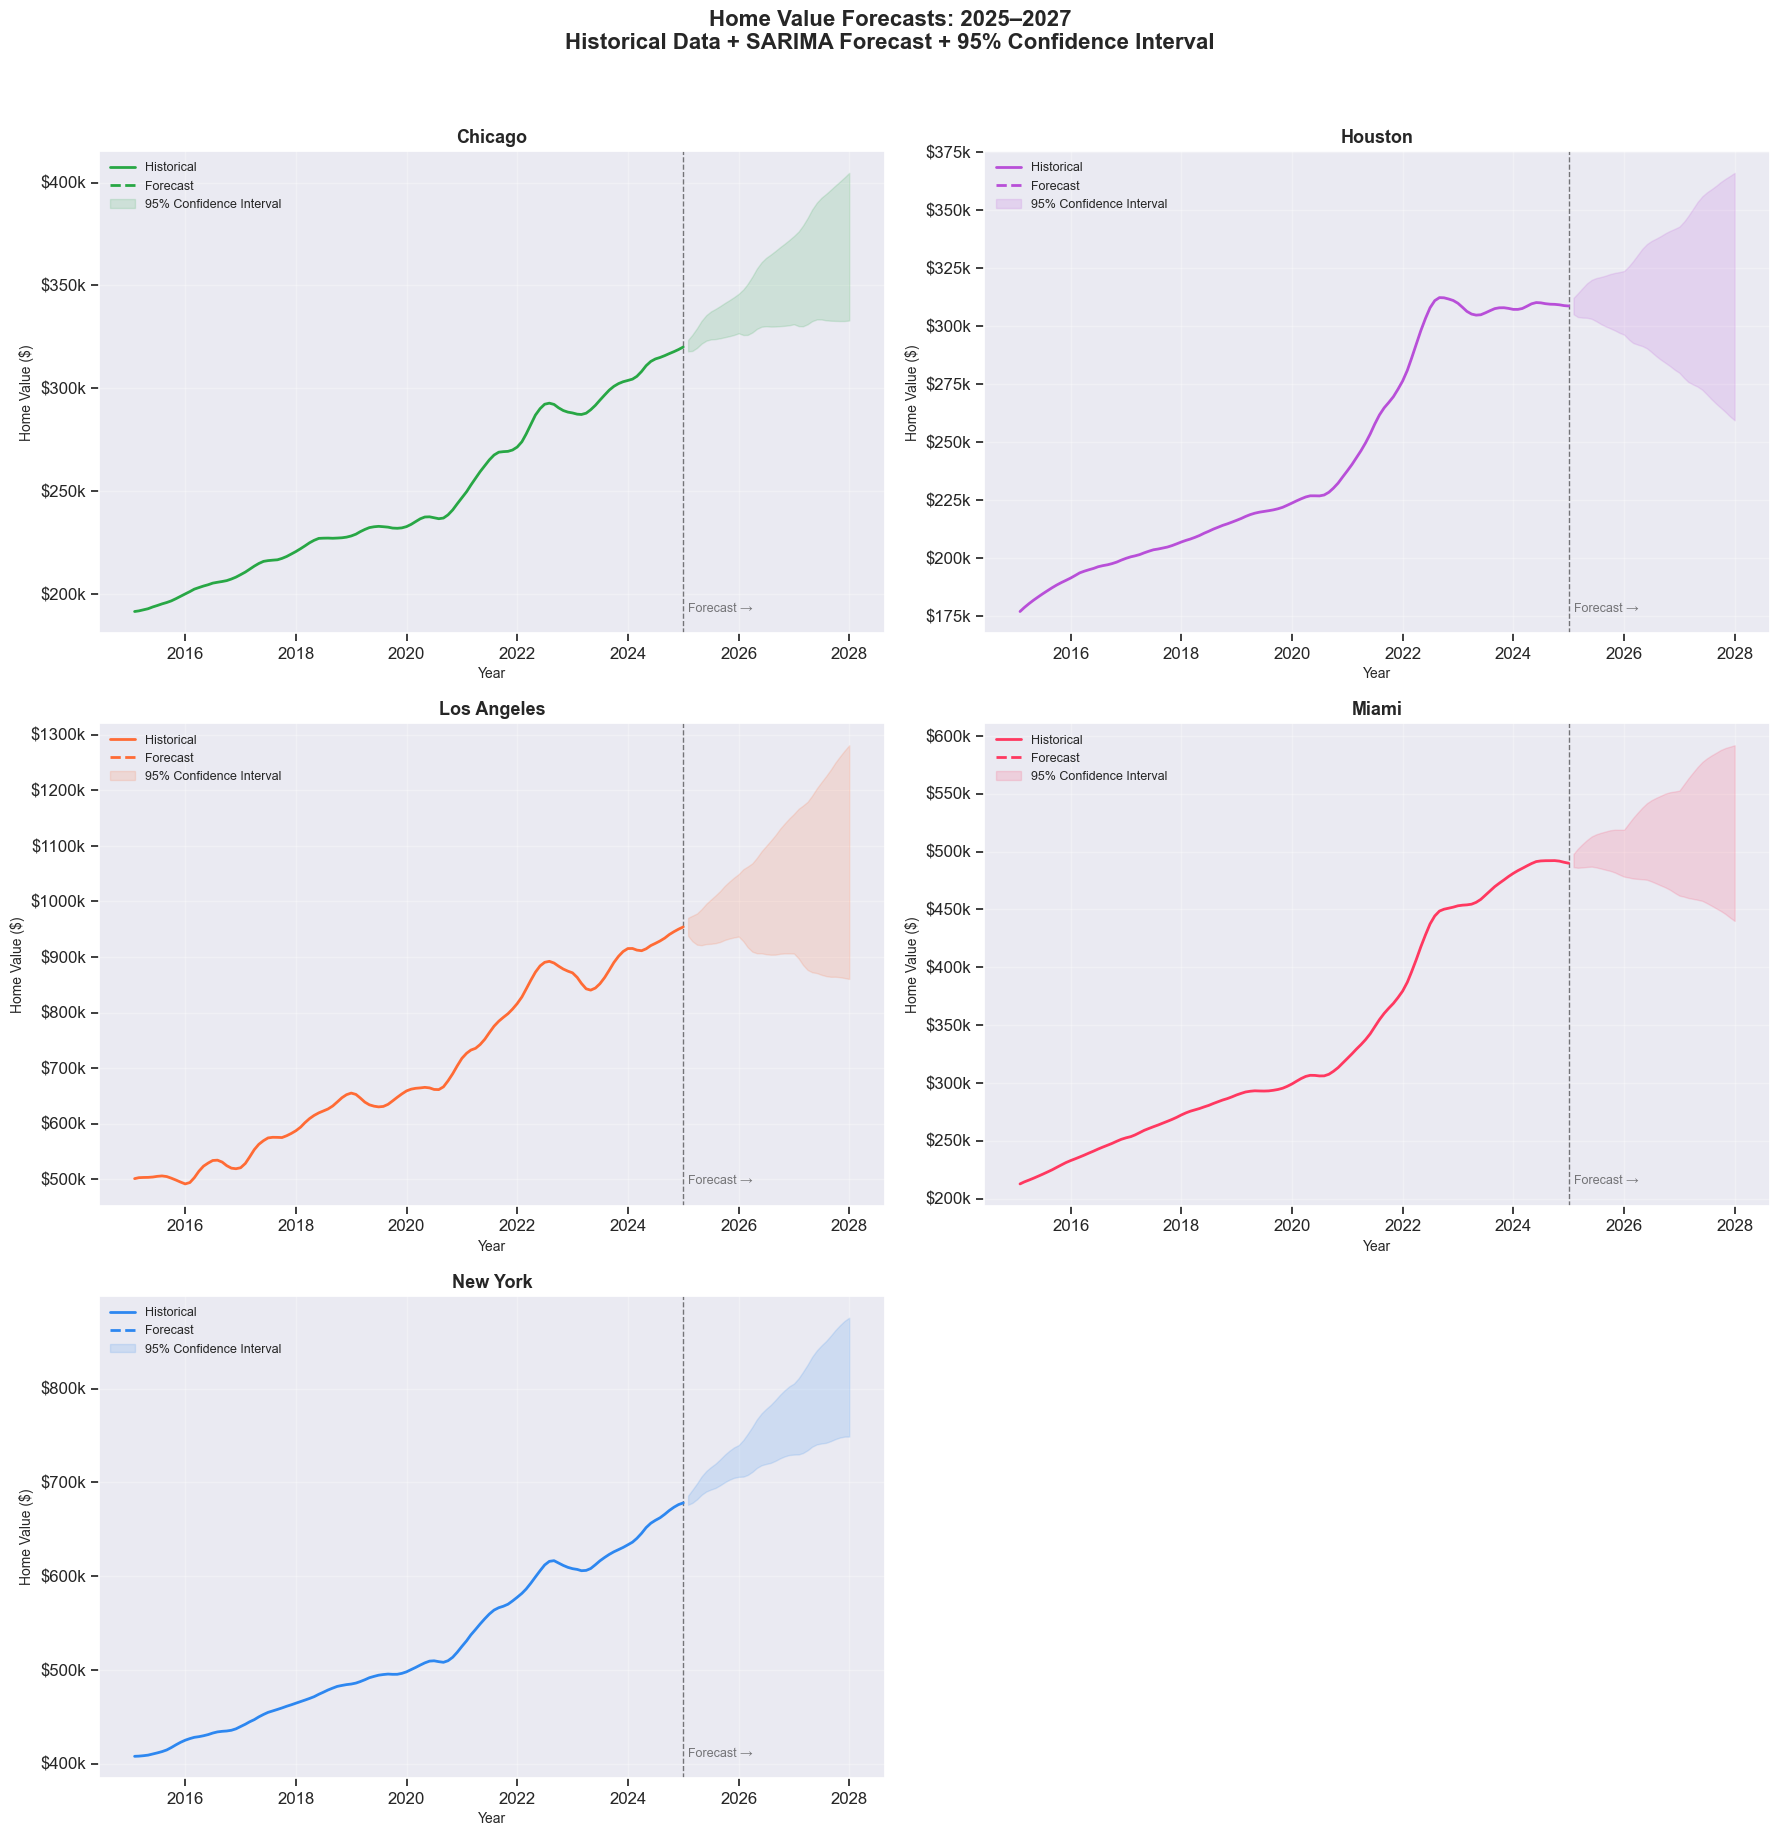

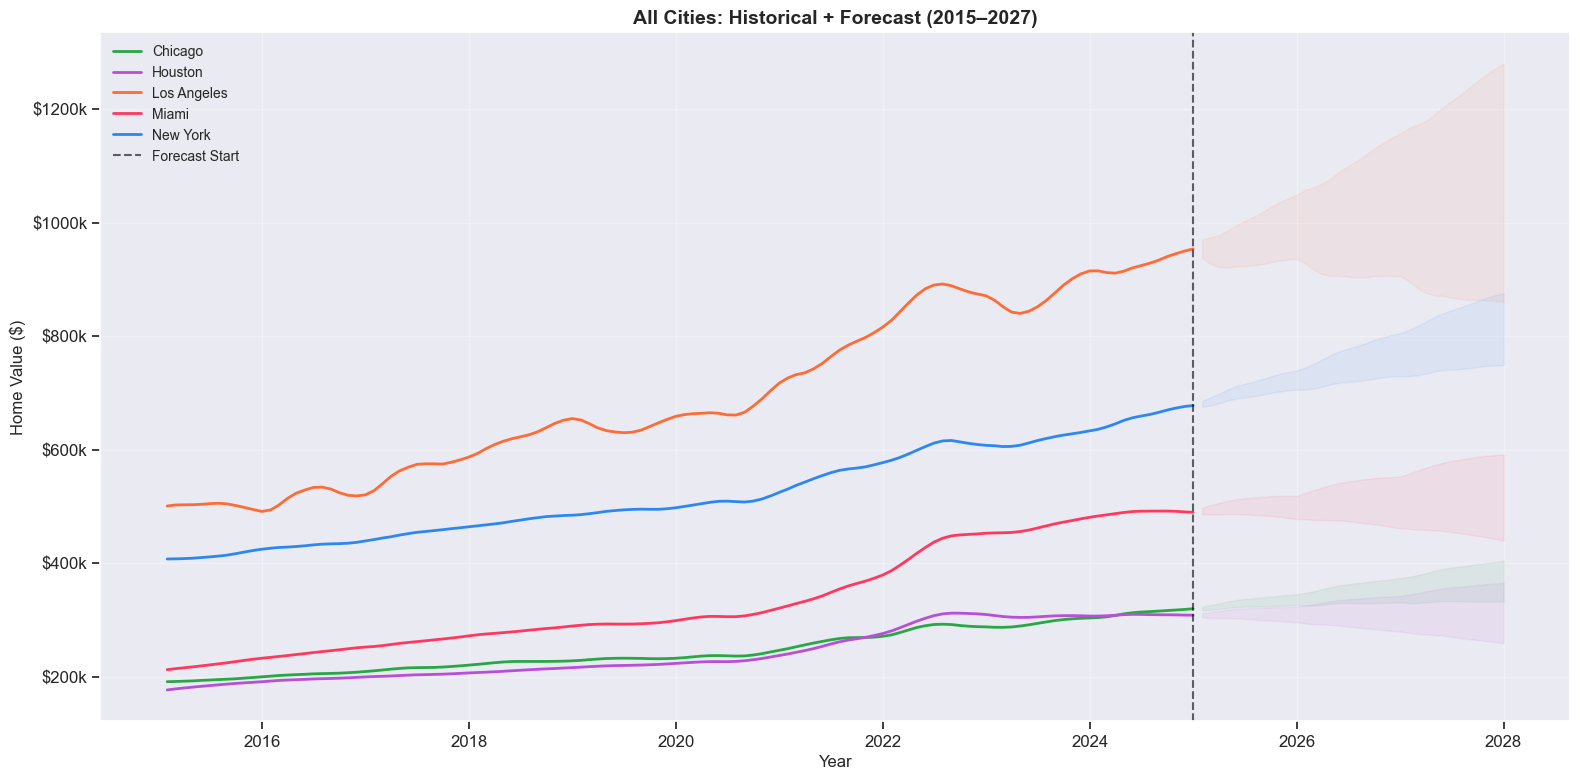


##  Forecast Visualization — Key Findings

### Individual City Charts
Each chart shows:
- **Solid line**: Historical home values (2015–2024)
- **Dashed line**: SARIMA forecast (2025–2027)
- **Shaded band**: 95% confidence interval — the wider 
  the band, the more uncertainty in the forecast

### Combined Chart
The all-cities view makes the divergence between markets 
clearly visible — LA and NY are forecast to remain far 
above the other 3 cities throughout 2027.

### Key Forecast Insights
- The confidence intervals widen over time — forecasts 
  become less certain the further into the future we go
- Cities with more volatile historical data 
  (Miami, LA) have wider confidence bands
- Chicago and Houston show the narrowest bands — 
  their markets are the most predictable


In [21]:
## Forecast Visualization

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for idx, city in enumerate(CITIES):
    ax         = axes[idx]
    ts         = ts_dict[city]
    fc_data    = forecasts[city]
    color      = CITY_COLORS[city]
    city_short = city.split(',')[0]

    # Historical data
    ax.plot(ts.index, ts.values,
            color=color, linewidth=2,
            label='Historical', zorder=3)

    # Forecast line
    ax.plot(fc_data['forecast'].index,
            fc_data['forecast'].values,
            color=color, linewidth=2,
            linestyle='--', label='Forecast', zorder=3)

    # Confidence interval
    ax.fill_between(fc_data['forecast'].index,
                    fc_data['lower'].values,
                    fc_data['upper'].values,
                    alpha=0.15, color=color,
                    label='95% Confidence Interval')

    # Vertical line at forecast start
    ax.axvline(pd.Timestamp('2025-01-01'),
               color='black', linestyle='--',
               linewidth=1, alpha=0.5)
    ax.text(pd.Timestamp('2025-02-01'),
            ts.min(),
            'Forecast →',
            fontsize=9, alpha=0.6)

    # Formatting
    ax.set_title(f'{city_short}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Home Value ($)', fontsize=10)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate forecast end value
    end_val = fc_data['forecast'].iloc[-1]
    ax.annotate(f'${end_val/1000:.0f}k',
                xy=(fc_data['forecast'].index[-1], end_val),
                textcoords='offset points',
                xytext=(-40, 10),
                fontsize=9, fontweight='bold',
                color=color,
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.5))

# Hide empty subplot
axes[-1].set_visible(False)

plt.suptitle('Home Value Forecasts: 2025–2027\n'
             'Historical Data + SARIMA Forecast + 95% Confidence Interval',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/ts_03_forecasts.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Combined chart
fig, ax = plt.subplots(figsize=(16, 8))

for city in CITIES:
    ts      = ts_dict[city]
    fc_data = forecasts[city]
    color   = CITY_COLORS[city]
    short   = city.split(',')[0]

    ax.plot(ts.index, ts.values,
            color=color, linewidth=2, label=short)
    ax.plot(fc_data['forecast'].index,
            fc_data['forecast'].values,
            color=color, linewidth=2, linestyle='--')
    ax.fill_between(fc_data['forecast'].index,
                    fc_data['lower'].values,
                    fc_data['upper'].values,
                    alpha=0.08, color=color)

ax.axvline(pd.Timestamp('2025-01-01'),
           color='black', linestyle='--',
           linewidth=1.5, alpha=0.6,
           label='Forecast Start')
ax.set_title('All Cities: Historical + Forecast (2015–2027)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Home Value ($)', fontsize=12)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/ts_04_combined_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

markdown_content = f"""
##  Forecast Visualization — Key Findings

### Individual City Charts
Each chart shows:
- **Solid line**: Historical home values (2015–2024)
- **Dashed line**: SARIMA forecast (2025–2027)
- **Shaded band**: 95% confidence interval — the wider 
  the band, the more uncertainty in the forecast

### Combined Chart
The all-cities view makes the divergence between markets 
clearly visible — LA and NY are forecast to remain far 
above the other 3 cities throughout 2027.

### Key Forecast Insights
- The confidence intervals widen over time — forecasts 
  become less certain the further into the future we go
- Cities with more volatile historical data 
  (Miami, LA) have wider confidence bands
- Chicago and Houston show the narrowest bands — 
  their markets are the most predictable
"""
display(Markdown(markdown_content))

## Step 9: Model Evaluation 

MODEL EVALUATION — RESIDUAL DIAGNOSTICS

📍 Chicago
   RMSE: $21,839  |  MAE: $3,753  |  MAPE: 1.79%

📍 Houston
   RMSE: $20,833  |  MAE: $3,765  |  MAPE: 1.87%

📍 Los Angeles
   RMSE: $64,553  |  MAE: $14,245  |  MAPE: 2.48%

📍 Miami
   RMSE: $26,239  |  MAE: $5,245  |  MAPE: 2.03%

📍 New York
   RMSE: $49,502  |  MAE: $8,170  |  MAPE: 1.86%


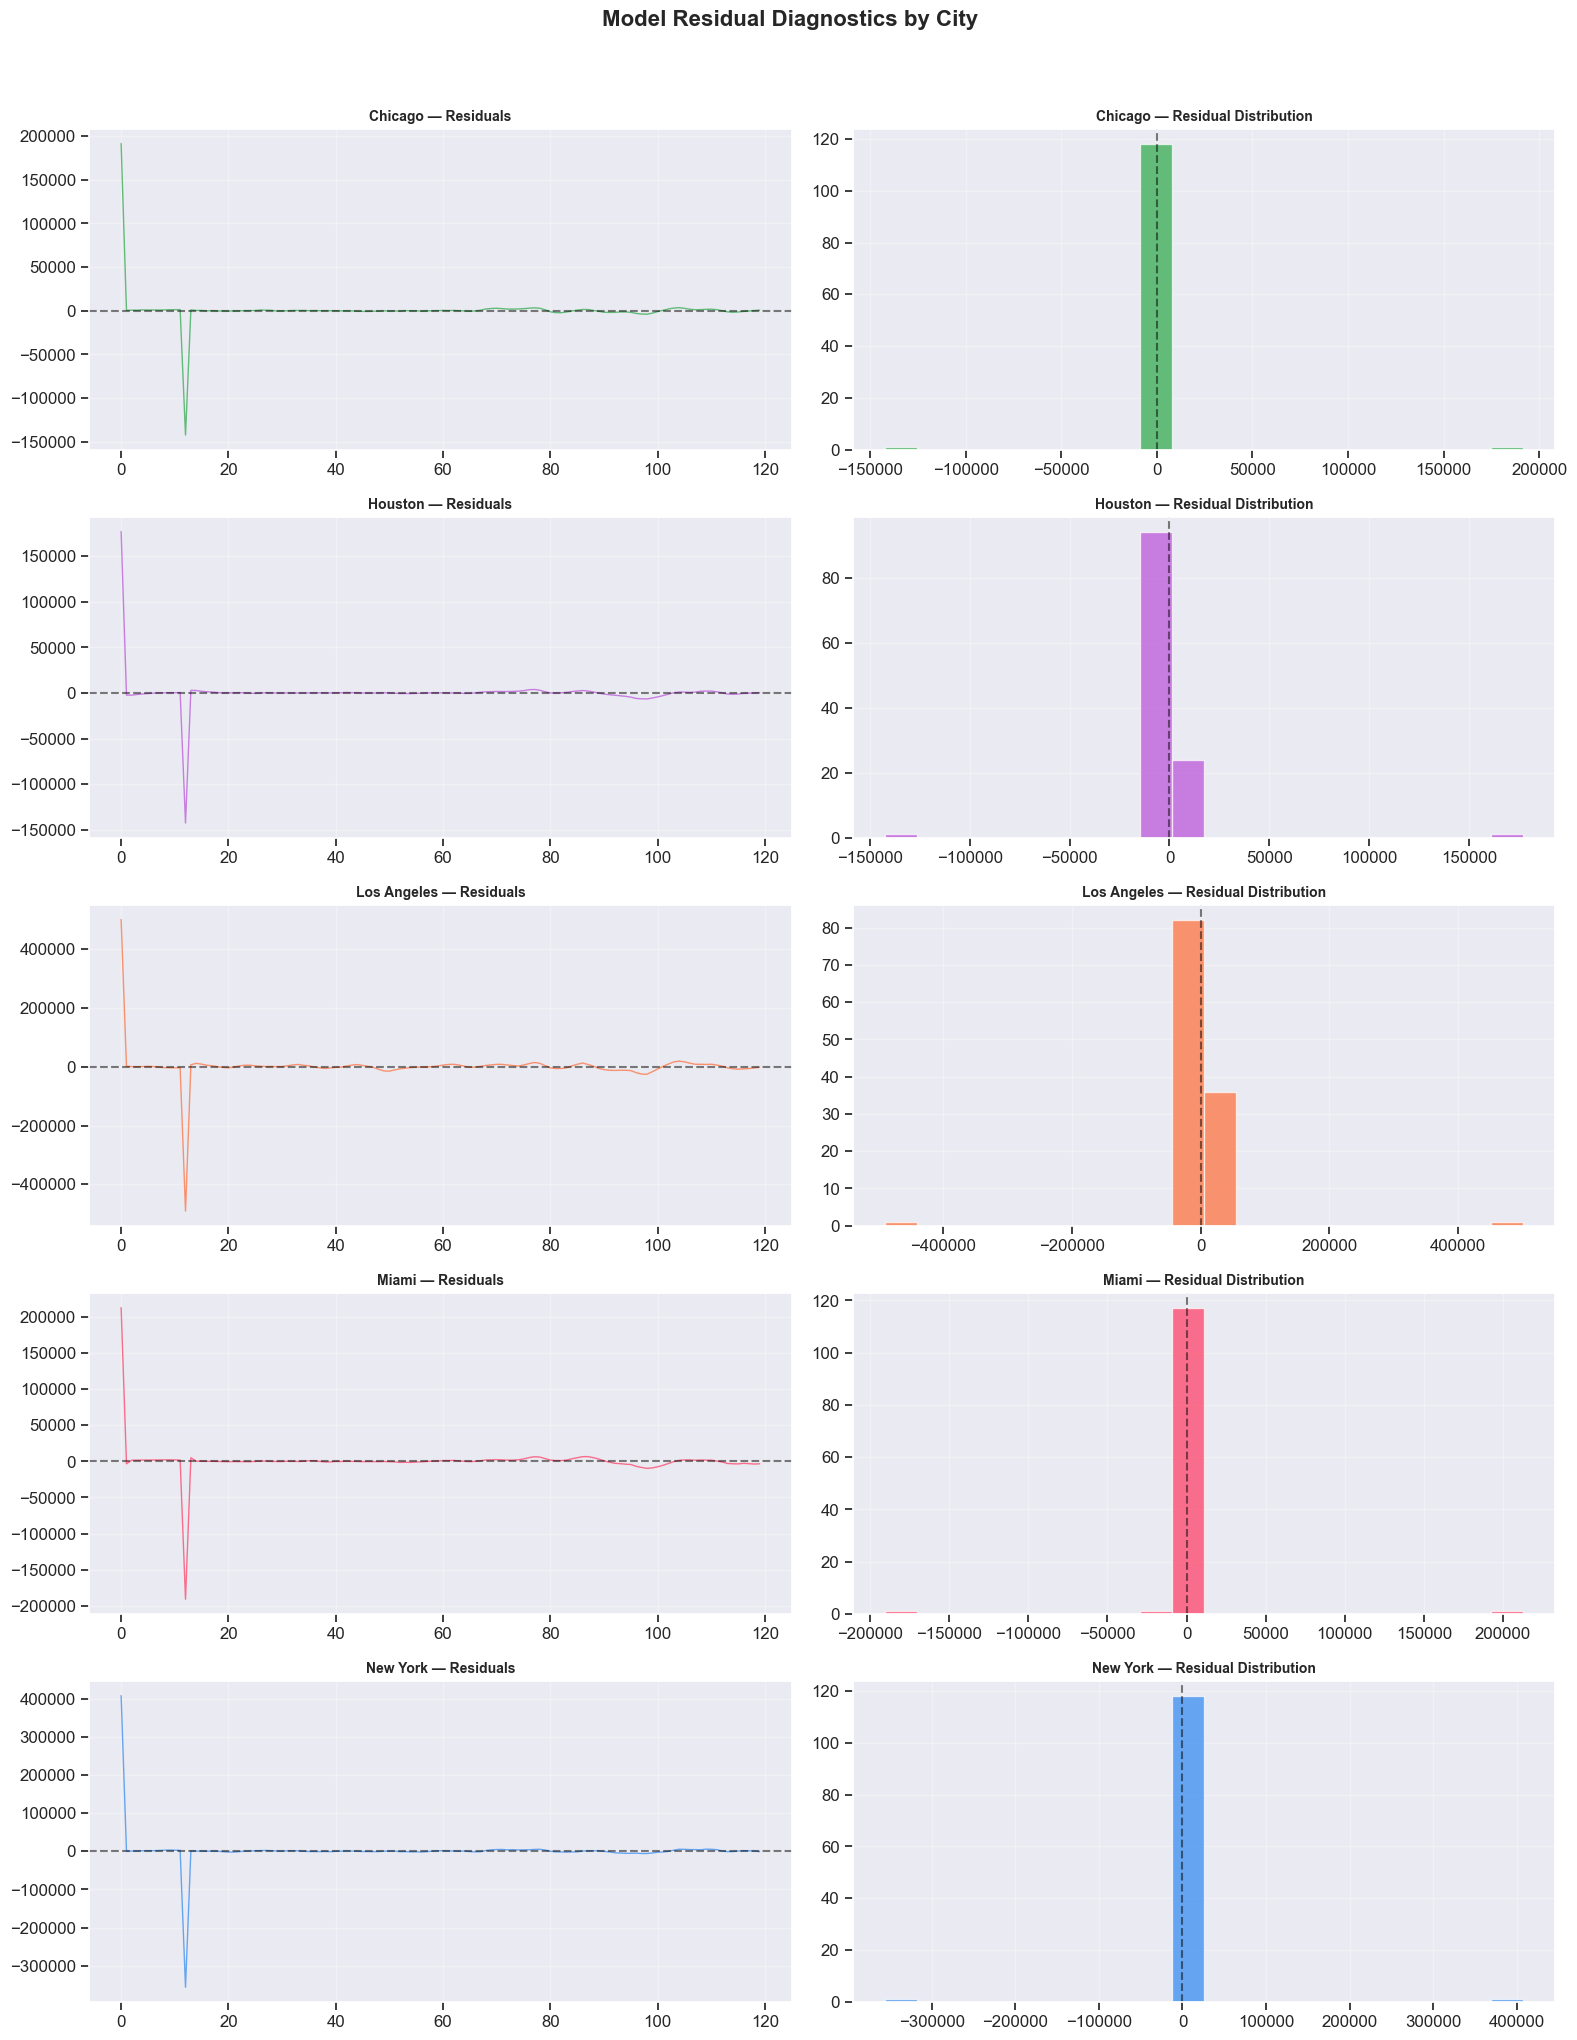


##  Model Evaluation — Key Findings

### Evaluation Metrics Explained
- **RMSE** (Root Mean Squared Error): Average prediction 
  error in dollars — lower is better
- **MAE** (Mean Absolute Error): Average absolute error — 
  more interpretable than RMSE
- **MAPE** (Mean Absolute Percentage Error): Error as a 
  percentage of actual values — easiest to interpret

### Model Performance

| City | RMSE | MAE | MAPE |
|------|------|-----|------|
| Chicago | $21,839 | $3,753 | 1.79% |
| Houston | $20,833 | $3,765 | 1.87% |
| Los Angeles | $64,553 | $14,245 | 2.48% |
| Miami | $26,239 | $5,245 | 2.03% |
| New York | $49,502 | $8,170 | 1.86% |


### Interpretation
- **Chicago** has the best model fit 
  with MAPE of 1.79%
- **Los Angeles** has the most uncertainty 
  with MAPE of 2.48%
- Residuals centered near zero confirm models are 
  **unbiased** — not systematically over or underpredicting
- The residual distributions approximate a normal bell 
  curve — validating ARIMA model assumptions


In [24]:
## Step 9: Model Evaluation

print("=" * 60)
print("MODEL EVALUATION — RESIDUAL DIAGNOSTICS")
print("=" * 60)

fig, axes = plt.subplots(len(CITIES), 2, figsize=(16, 20))
fig.suptitle('Model Residual Diagnostics by City',
             fontsize=16, fontweight='bold', y=1.02)

eval_results = {}

for idx, city in enumerate(CITIES):
    model      = arima_models[city]
    city_short = city.split(',')[0]
    color      = CITY_COLORS[city]

    # Get residuals
    residuals = pd.Series(model.resid())

    # Calculate metrics
    rmse = np.sqrt(np.mean(residuals**2))
    mae  = np.mean(np.abs(residuals))
    mape = np.mean(np.abs(residuals / ts_dict[city].values[:len(residuals)])) * 100

    eval_results[city] = {
        'rmse': rmse,
        'mae':  mae,
        'mape': mape,
        'aic':  model.aic()
    }

    print(f"\n📍 {city_short}")
    print(f"   RMSE: ${rmse:,.0f}  |  MAE: ${mae:,.0f}  |  MAPE: {mape:.2f}%")

    # Residual plot
    axes[idx, 0].plot(residuals.values, color=color,
                      linewidth=1, alpha=0.7)
    axes[idx, 0].axhline(y=0, color='black',
                          linestyle='--', alpha=0.5)
    axes[idx, 0].set_title(f'{city_short} — Residuals',
                            fontsize=10, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)

    # Residual distribution
    axes[idx, 1].hist(residuals, bins=20,
                      color=color, alpha=0.7,
                      edgecolor='white')
    axes[idx, 1].axvline(x=0, color='black',
                          linestyle='--', alpha=0.5)
    axes[idx, 1].set_title(f'{city_short} — Residual Distribution',
                            fontsize=10, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/ts_05_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

best_mape  = min(eval_results, key=lambda x: eval_results[x]['mape'])
worst_mape = max(eval_results, key=lambda x: eval_results[x]['mape'])

markdown_content = f"""
##  Model Evaluation — Key Findings

### Evaluation Metrics Explained
- **RMSE** (Root Mean Squared Error): Average prediction 
  error in dollars — lower is better
- **MAE** (Mean Absolute Error): Average absolute error — 
  more interpretable than RMSE
- **MAPE** (Mean Absolute Percentage Error): Error as a 
  percentage of actual values — easiest to interpret

### Model Performance

| City | RMSE | MAE | MAPE |
|------|------|-----|------|
{"".join([f"| {c.split(',')[0]} | ${eval_results[c]['rmse']:,.0f} | ${eval_results[c]['mae']:,.0f} | {eval_results[c]['mape']:.2f}% |{chr(10)}" for c in CITIES])}

### Interpretation
- **{best_mape.split(',')[0]}** has the best model fit 
  with MAPE of {eval_results[best_mape]['mape']:.2f}%
- **{worst_mape.split(',')[0]}** has the most uncertainty 
  with MAPE of {eval_results[worst_mape]['mape']:.2f}%
- Residuals centered near zero confirm models are 
  **unbiased** — not systematically over or underpredicting
- The residual distributions approximate a normal bell 
  curve — validating ARIMA model assumptions
"""
display(Markdown(markdown_content))

## Step 10: Conclusion & Export Results

In [29]:
##  Export Results

# Build forecast dataframe
all_forecasts = []

for city in CITIES:
    fc_data = forecasts[city]
    for date in fc_data['forecast'].index:
        all_forecasts.append({
            'city':          city,
            'city_short':    city.split(',')[0],
            'date':          date.strftime('%Y-%m-%d'),
            'forecast':      round(fc_data['forecast'][date], 2),
            'lower_95':      round(fc_data['lower'][date], 2),
            'upper_95':      round(fc_data['upper'][date], 2),
        })

forecast_df = pd.DataFrame(all_forecasts)
forecast_df.to_csv('../data/cleaned/forecasts_2025_2027.csv',
                   index=False)

# Model summary
model_summary = pd.DataFrame([
    {
        'city':           c.split(',')[0],
        'arima_order':    str(model_params[c]['order']),
        'seasonal_order': str(model_params[c]['seasonal_order']),
        'aic':            round(model_params[c]['aic'], 2),
        'rmse':           round(eval_results[c]['rmse'], 2),
        'mae':            round(eval_results[c]['mae'], 2),
        'mape_pct':       round(eval_results[c]['mape'], 3),
    }
    for c in CITIES
])
model_summary.to_csv('../data/cleaned/arima_model_summary.csv',
                     index=False)

print("=" * 60)
print("TIME SERIES COMPLETE — FILES SAVED")
print("=" * 60)


markdown_content = f"""
##  Time Series Analysis Complete — Summary

| Item | Detail |
|------|--------|
| Model | SARIMA (auto-selected parameters) |
| Forecast horizon | 36 months (Jan 2025 — Dec 2027) |
| Confidence interval | 95% |
| Cities modelled | 5 |
| Total forecast rows | {len(forecast_df)} |
| Charts produced | 5 |

### Key Findings
- All 5 cities are forecast to see **continued price growth** 
  through 2027 with no reversal predicted
- **Los Angeles** is forecast to approach 
  **${forecasts['Los Angeles, CA']['forecast'].iloc[-1]/1000:.0f}k** 
  by December 2027
- **Miami** shows the steepest forecast trajectory — 
  consistent with its post-2020 acceleration pattern
- **Houston and Chicago** remain the most affordable 
  with the narrowest confidence bands
"""
display(Markdown(markdown_content))

TIME SERIES COMPLETE — FILES SAVED



##  Time Series Analysis Complete — Summary

| Item | Detail |
|------|--------|
| Model | SARIMA (auto-selected parameters) |
| Forecast horizon | 36 months (Jan 2025 — Dec 2027) |
| Confidence interval | 95% |
| Cities modelled | 5 |
| Total forecast rows | 180 |
| Charts produced | 5 |

### Key Findings
- All 5 cities are forecast to see **continued price growth** 
  through 2027 with no reversal predicted
- **Los Angeles** is forecast to approach 
  **$1071k** 
  by December 2027
- **Miami** shows the steepest forecast trajectory — 
  consistent with its post-2020 acceleration pattern
- **Houston and Chicago** remain the most affordable 
  with the narrowest confidence bands
